In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns   
import pandas as pd
from scipy import stats

df = pd.read_csv('../../../Data/processed/cleaned_customer_data.csv')

## Customer Value EDA
Goal: Evaluate whether customer value indicators explain churn with statistical and practical significance.

### Scope
1. `Lifetime_Value`
2. `Credit_Balance`

### Workflow
1. Correlation screening
2. Distribution comparison by churn group
3. Mann-Whitney U test + rank-biserial effect size
4. Executive summary and export

In [2]:
Customer_Value_features = [
    "Lifetime_Value",
    "Credit_Balance",
]

In [3]:
# Correlation with churn
corr_cv = df[Customer_Value_features].corrwith(df["Churned"]).sort_values()
corr_cv.to_frame("corr_with_churn")

,corr_with_churn
Credit_Balance,-0.147990
Lifetime_Value,-0.010684


## Distribution by Churn Group

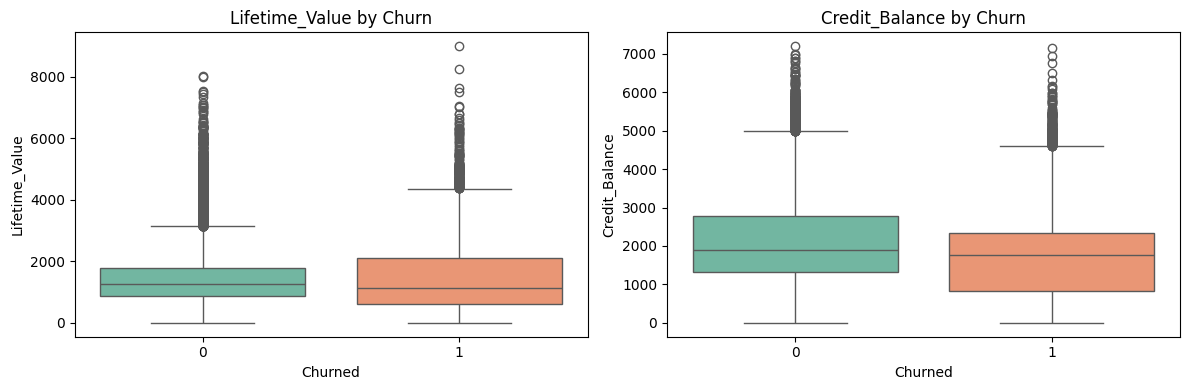

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for i, col in enumerate(Customer_Value_features):
    sns.boxplot(
        data=df,
        x="Churned",
        y=col,
        hue="Churned",
        dodge=False,
        legend=False,
        ax=axes[i],
        palette="Set2"
    )
    axes[i].set_title(f"{col} by Churn")

plt.tight_layout()
plt.show()

## Group Summary + Statistical Test

In [ ]:
def rank_biserial_from_u(u_stat, n_churn, n_non_churn):
    auc_probability = u_stat / (n_churn * n_non_churn)
    return 2 * auc_probability - 1


def effect_label(value):
    abs_value = abs(value)
    if abs_value >= 0.5:
        return "Large"
    if abs_value >= 0.3:
        return "Medium"
    if abs_value >= 0.1:
        return "Small"
    return "Negligible"


summary = df.groupby("Churned")[Customer_Value_features].mean().T
summary.columns = ["Not Churned (0)", "Churned (1)"]
summary["Diff (0-1)"] = summary["Not Churned (0)"] - summary["Churned (1)"]
summary = summary.sort_values("Diff (0-1)", ascending=False)


test_rows = []
for col in Customer_Value_features:
    g0 = df.loc[df["Churned"] == 0, col].dropna()
    g1 = df.loc[df["Churned"] == 1, col].dropna()
    stat, p = stats.mannwhitneyu(g1, g0, alternative="two-sided")
    rb = rank_biserial_from_u(stat, len(g1), len(g0))
    test_rows.append(
        {
            "feature": col,
            "u_stat": stat,
            "p_value": p,
            "rank_biserial": rb,
            "effect_size_label": effect_label(rb),
        }
    )

test_df = pd.DataFrame(test_rows).sort_values("p_value")
customer_value_summary = summary.reset_index().rename(columns={"index": "feature"}).merge(test_df, on="feature", how="left")

print("Executive Insight: Customer Value vs Churn")
print("-----------------------------------------")
for _, row in customer_value_summary.iterrows():
    direction = "higher" if row["Diff (0-1)"] < 0 else "lower"
    print(
        f"- {row['feature']}: churn group average is {direction} than non-churn, "
        f"effect={row['effect_size_label']} (rb={row['rank_biserial']:.3f}), p={row['p_value']:.2e}"
    )

customer_value_summary.to_csv("../../../Data/processed/customer_value_professional_summary.csv", index=False)
print("Saved: Data/processed/customer_value_professional_summary.csv")

customer_value_summary

,feature,u_stat,p_value
1,Credit_Balance,305433782.0,3.533271e-242
0,Lifetime_Value,274943119.0,3.905710e-35


## Professional Insight Summary

- `Credit_Balance` and `Lifetime_Value` show statistically meaningful differences between churn and non-churn groups in this dataset.
- Correlation alone can underestimate practical separation, so effect size and group-gap views are critical.
- Customer value features should be treated as supporting churn signals and combined with engagement and purchase behavior.

### Recommendation
Use these features in a multi-feature churn pipeline and prioritize features with both low p-values and non-negligible effect sizes.

In [6]:
# Optional: quick interpretation helper
alpha = 0.05
test_df.assign(significant=test_df["p_value"] < alpha)

,feature,u_stat,p_value,significant
1,Credit_Balance,305433782.0,3.533271e-242,True
0,Lifetime_Value,274943119.0,3.905710e-35,True
